In [1]:
# Импорты, seed и устройство

import os
import random
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
from torchvision import transforms

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


In [2]:
# Для CIFAR10 нормализация по трём каналам
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_full = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform
)
test_ds = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform
)

class_names = train_full.classes
print('Classes:', class_names)
print(f'Train size: {len(train_full)}, Test size: {len(test_ds)}')

# Разбиение train/val (80/20)
val_ratio = 0.2
val_size = int(len(train_full) * val_ratio)
train_size = len(train_full) - val_size
gen = torch.Generator().manual_seed(42)
train_ds, val_ds = random_split(train_full, [train_size, val_size], generator=gen)

BATCH_SIZE = 64
NUM_WORKERS = 0 if os.name == 'nt' else 2

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train size: {len(train_ds)}, Val size: {len(val_ds)}, Test size: {len(test_ds)}')
print(f'Input shape: {train_ds[0][0].shape}')  # (3, 32, 32)

Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Train size: 50000, Test size: 10000
Train size: 40000, Val size: 10000, Test size: 10000
Input shape: torch.Size([3, 32, 32])


In [3]:
# 3. Модель MLP и вспомогательные функции


class MLP(nn.Module):
    def __init__(self, input_dim=3*32*32, hidden_dims=(256,128), num_classes=10,
                 activation='relu', dropout_p=0.0, use_batchnorm=False):
        super().__init__()
        act = {'relu': nn.ReLU, 'tanh': nn.Tanh}[activation.lower()]
        layers = [nn.Flatten()]
        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h
        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

def accuracy_from_logits(logits, y):
    preds = torch.argmax(logits, dim=1)
    return (preds == y).float().mean().item()

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, total_acc, n = 0.0, 0.0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n += 1
    return total_loss / n, total_acc / n

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, total_acc, n = 0.0, 0.0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n += 1
    return total_loss / n, total_acc / n

class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score, model):
        if self.best_score is None or score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False
        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

def fit(model, train_loader, val_loader, optimizer, criterion, device,
        epochs=20, early_stopping=None, verbose=True):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    for epoch in range(1, epochs+1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)
        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(va_loss)
        history['val_acc'].append(va_acc)
        if verbose:
            print(f'Epoch {epoch:2d}/{epochs} | train loss={tr_loss:.4f}, acc={tr_acc:.4f} | val loss={va_loss:.4f}, acc={va_acc:.4f}')
        if early_stopping is not None:
            if early_stopping.step(va_acc, model):
                print(f'Early stopping at epoch {epoch}, best val_acc={early_stopping.best_score:.4f}')
                early_stopping.restore_best(model)
                break
    return history

In [4]:
# 4. Часть A: регуляризация (E1–E4)

criterion = nn.CrossEntropyLoss()
results = []

# E1 – baseline
set_seed(42)
model_e1 = MLP(hidden_dims=(256,128), dropout_p=0.0, use_batchnorm=False).to(device)
optimizer = optim.Adam(model_e1.parameters(), lr=1e-3)
hist_e1 = fit(model_e1, train_loader, val_loader, optimizer, criterion, device, epochs=30)
best_val_acc = max(hist_e1['val_acc'])
results.append({
    'experiment_id': 'E1', 'dataset': 'CIFAR10', 'seed': 42,
    'model_summary': '2x256,128, ReLU, no DO, no BN',
    'optimizer': 'Adam', 'lr': 1e-3, 'momentum': '', 'weight_decay': 0,
    'epochs_trained': len(hist_e1['train_loss']),
    'best_val_accuracy': best_val_acc, 'best_val_loss': min(hist_e1['val_loss'])
})

Epoch  1/30 | train loss=1.6642, acc=0.4113 | val loss=1.5344, acc=0.4568
Epoch  2/30 | train loss=1.4580, acc=0.4846 | val loss=1.4768, acc=0.4870
Epoch  3/30 | train loss=1.3515, acc=0.5219 | val loss=1.4029, acc=0.5139
Epoch  4/30 | train loss=1.2696, acc=0.5497 | val loss=1.4369, acc=0.4991
Epoch  5/30 | train loss=1.1931, acc=0.5774 | val loss=1.4009, acc=0.5233
Epoch  6/30 | train loss=1.1203, acc=0.6034 | val loss=1.4144, acc=0.5277
Epoch  7/30 | train loss=1.0565, acc=0.6247 | val loss=1.4245, acc=0.5253
Epoch  8/30 | train loss=0.9891, acc=0.6509 | val loss=1.4413, acc=0.5257
Epoch  9/30 | train loss=0.9235, acc=0.6725 | val loss=1.4888, acc=0.5234
Epoch 10/30 | train loss=0.8686, acc=0.6902 | val loss=1.5203, acc=0.5228
Epoch 11/30 | train loss=0.8119, acc=0.7111 | val loss=1.5731, acc=0.5199
Epoch 12/30 | train loss=0.7601, acc=0.7301 | val loss=1.6476, acc=0.5227
Epoch 13/30 | train loss=0.7135, acc=0.7461 | val loss=1.7048, acc=0.5221
Epoch 14/30 | train loss=0.6662, acc=0

In [5]:
# E2 – Dropout (p=0.3)
set_seed(42)
model_e2 = MLP(hidden_dims=(256,128), dropout_p=0.3, use_batchnorm=False).to(device)
optimizer = optim.Adam(model_e2.parameters(), lr=1e-3)
hist_e2 = fit(model_e2, train_loader, val_loader, optimizer, criterion, device, epochs=30)
best_val_acc = max(hist_e2['val_acc'])
results.append({
    'experiment_id': 'E2', 'dataset': 'CIFAR10', 'seed': 42,
    'model_summary': '2x256,128, ReLU, DO=0.3, no BN',
    'optimizer': 'Adam', 'lr': 1e-3, 'momentum': '', 'weight_decay': 0,
    'epochs_trained': len(hist_e2['train_loss']),
    'best_val_accuracy': best_val_acc, 'best_val_loss': min(hist_e2['val_loss'])
})


Epoch  1/30 | train loss=1.7913, acc=0.3583 | val loss=1.6055, acc=0.4258
Epoch  2/30 | train loss=1.6430, acc=0.4185 | val loss=1.5323, acc=0.4589
Epoch  3/30 | train loss=1.5784, acc=0.4428 | val loss=1.4876, acc=0.4727
Epoch  4/30 | train loss=1.5311, acc=0.4540 | val loss=1.4742, acc=0.4797
Epoch  5/30 | train loss=1.4958, acc=0.4670 | val loss=1.4388, acc=0.4942
Epoch  6/30 | train loss=1.4673, acc=0.4794 | val loss=1.4145, acc=0.5015
Epoch  7/30 | train loss=1.4420, acc=0.4875 | val loss=1.4108, acc=0.5027
Epoch  8/30 | train loss=1.4130, acc=0.4950 | val loss=1.3880, acc=0.5109
Epoch  9/30 | train loss=1.3835, acc=0.5067 | val loss=1.3963, acc=0.5057
Epoch 10/30 | train loss=1.3736, acc=0.5112 | val loss=1.3838, acc=0.5104
Epoch 11/30 | train loss=1.3465, acc=0.5193 | val loss=1.3689, acc=0.5191
Epoch 12/30 | train loss=1.3274, acc=0.5258 | val loss=1.3775, acc=0.5135
Epoch 13/30 | train loss=1.3127, acc=0.5294 | val loss=1.3545, acc=0.5237
Epoch 14/30 | train loss=1.2949, acc=0

In [6]:
# E3 – BatchNorm
set_seed(42)
model_e3 = MLP(hidden_dims=(256,128), dropout_p=0.0, use_batchnorm=True).to(device)
optimizer = optim.Adam(model_e3.parameters(), lr=1e-3)
hist_e3 = fit(model_e3, train_loader, val_loader, optimizer, criterion, device, epochs=30)
best_val_acc = max(hist_e3['val_acc'])
results.append({
    'experiment_id': 'E3', 'dataset': 'CIFAR10', 'seed': 42,
    'model_summary': '2x256,128, ReLU, no DO, BN',
    'optimizer': 'Adam', 'lr': 1e-3, 'momentum': '', 'weight_decay': 0,
    'epochs_trained': len(hist_e3['train_loss']),
    'best_val_accuracy': best_val_acc, 'best_val_loss': min(hist_e3['val_loss'])
})


Epoch  1/30 | train loss=1.6373, acc=0.4166 | val loss=1.5006, acc=0.4643
Epoch  2/30 | train loss=1.4249, acc=0.4897 | val loss=1.3809, acc=0.5142
Epoch  3/30 | train loss=1.3257, acc=0.5275 | val loss=1.3641, acc=0.5184
Epoch  4/30 | train loss=1.2496, acc=0.5537 | val loss=1.3455, acc=0.5204
Epoch  5/30 | train loss=1.1799, acc=0.5812 | val loss=1.3028, acc=0.5402
Epoch  6/30 | train loss=1.1231, acc=0.5961 | val loss=1.3116, acc=0.5393
Epoch  7/30 | train loss=1.0689, acc=0.6216 | val loss=1.3195, acc=0.5401
Epoch  8/30 | train loss=1.0152, acc=0.6378 | val loss=1.3308, acc=0.5390
Epoch  9/30 | train loss=0.9644, acc=0.6568 | val loss=1.3438, acc=0.5483
Epoch 10/30 | train loss=0.9148, acc=0.6752 | val loss=1.3456, acc=0.5405
Epoch 11/30 | train loss=0.8701, acc=0.6917 | val loss=1.3549, acc=0.5446
Epoch 12/30 | train loss=0.8281, acc=0.7056 | val loss=1.4271, acc=0.5339
Epoch 13/30 | train loss=0.7844, acc=0.7232 | val loss=1.4114, acc=0.5471
Epoch 14/30 | train loss=0.7440, acc=0

In [7]:
# E4 – лучший из E2/E3 + EarlyStopping (лучший по val_acc – E2)
set_seed(42)
model_e4 = MLP(hidden_dims=(256,128), dropout_p=0.3, use_batchnorm=False).to(device)
optimizer = optim.Adam(model_e4.parameters(), lr=1e-3)
early_stop = EarlyStopping(patience=4, min_delta=0.0005)
hist_e4 = fit(model_e4, train_loader, val_loader, optimizer, criterion, device,
              epochs=50, early_stopping=early_stop)
best_val_acc = early_stop.best_score
results.append({
    'experiment_id': 'E4', 'dataset': 'CIFAR10', 'seed': 42,
    'model_summary': '2x256,128, ReLU, DO=0.3, no BN + ES',
    'optimizer': 'Adam', 'lr': 1e-3, 'momentum': '', 'weight_decay': 0,
    'epochs_trained': len(hist_e4['train_loss']),
    'best_val_accuracy': best_val_acc, 'best_val_loss': min(hist_e4['val_loss'])
})


Epoch  1/50 | train loss=1.7913, acc=0.3583 | val loss=1.6055, acc=0.4258
Epoch  2/50 | train loss=1.6430, acc=0.4185 | val loss=1.5323, acc=0.4589
Epoch  3/50 | train loss=1.5784, acc=0.4428 | val loss=1.4876, acc=0.4727
Epoch  4/50 | train loss=1.5311, acc=0.4540 | val loss=1.4742, acc=0.4797
Epoch  5/50 | train loss=1.4958, acc=0.4670 | val loss=1.4388, acc=0.4942
Epoch  6/50 | train loss=1.4673, acc=0.4794 | val loss=1.4145, acc=0.5015
Epoch  7/50 | train loss=1.4420, acc=0.4875 | val loss=1.4108, acc=0.5027
Epoch  8/50 | train loss=1.4130, acc=0.4950 | val loss=1.3880, acc=0.5109
Epoch  9/50 | train loss=1.3835, acc=0.5067 | val loss=1.3963, acc=0.5057
Epoch 10/50 | train loss=1.3736, acc=0.5112 | val loss=1.3838, acc=0.5104
Epoch 11/50 | train loss=1.3465, acc=0.5193 | val loss=1.3689, acc=0.5191
Epoch 12/50 | train loss=1.3274, acc=0.5258 | val loss=1.3775, acc=0.5135
Epoch 13/50 | train loss=1.3127, acc=0.5294 | val loss=1.3545, acc=0.5237
Epoch 14/50 | train loss=1.2949, acc=0

In [8]:
# 5. Часть B: оптимизация (O1–O3)

def run_exp(exp_id, optimizer_name, lr, momentum=None, weight_decay=0, epochs=15):
    set_seed(42)
    model = MLP(hidden_dims=(256,128), dropout_p=0.3, use_batchnorm=False).to(device)
    if optimizer_name.lower() == 'adam':
        opt = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        mom_str = ''
    else:
        opt = optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
        mom_str = momentum
    hist = fit(model, train_loader, val_loader, opt, criterion, device,
               epochs=epochs, verbose=False)
    best_val_acc = max(hist['val_acc'])
    results.append({
        'experiment_id': exp_id, 'dataset': 'CIFAR10', 'seed': 42,
        'model_summary': '2x256,128, ReLU, DO=0.3, no BN',
        'optimizer': optimizer_name, 'lr': lr, 'momentum': mom_str, 'weight_decay': weight_decay,
        'epochs_trained': len(hist['train_loss']),
        'best_val_accuracy': best_val_acc, 'best_val_loss': min(hist['val_loss'])
    })
    return hist, model

# O1 – слишком большой LR (Adam, 1e-1)
hist_o1, _ = run_exp('O1', 'Adam', 1e-1, epochs=8)

# O2 – слишком маленький LR (Adam, 1e-5)
hist_o2, _ = run_exp('O2', 'Adam', 1e-5, epochs=8)

# O3 – SGD+momentum+weight decay (lr=1e-2, momentum=0.9, wd=1e-4)
hist_o3, _ = run_exp('O3', 'SGD', 1e-2, momentum=0.9, weight_decay=1e-4, epochs=15)

In [9]:
## 6. Сохранение результатов

df = pd.DataFrame(results)
df.to_csv('./artifacts/runs.csv', index=False)
print(df)

torch.save(model_e4.state_dict(), './artifacts/best_model.pt')
best_config = {
    'dataset': 'CIFAR10',
    'model': 'MLP',
    'hidden_dims': [256,128],
    'activation': 'relu',
    'dropout_p': 0.3,
    'use_batchnorm': False,
    'optimizer': 'Adam',
    'lr': 1e-3,
    'batch_size': BATCH_SIZE,
    'seed': 42,
    'best_val_accuracy': best_val_acc
}
with open('./artifacts/best_config.json', 'w') as f:
    json.dump(best_config, f, indent=2)

  experiment_id  dataset  seed                        model_summary optimizer  \
0            E1  CIFAR10    42        2x256,128, ReLU, no DO, no BN      Adam   
1            E2  CIFAR10    42       2x256,128, ReLU, DO=0.3, no BN      Adam   
2            E3  CIFAR10    42           2x256,128, ReLU, no DO, BN      Adam   
3            E4  CIFAR10    42  2x256,128, ReLU, DO=0.3, no BN + ES      Adam   
4            O1  CIFAR10    42       2x256,128, ReLU, DO=0.3, no BN      Adam   
5            O2  CIFAR10    42       2x256,128, ReLU, DO=0.3, no BN      Adam   
6            O3  CIFAR10    42       2x256,128, ReLU, DO=0.3, no BN       SGD   

        lr momentum  weight_decay  epochs_trained  best_val_accuracy  \
0  0.00100                 0.0000              30           0.527667   
1  0.00100                 0.0000              30           0.532643   
2  0.00100                 0.0000              30           0.548268   
3  0.00100                 0.0000              21           0.5

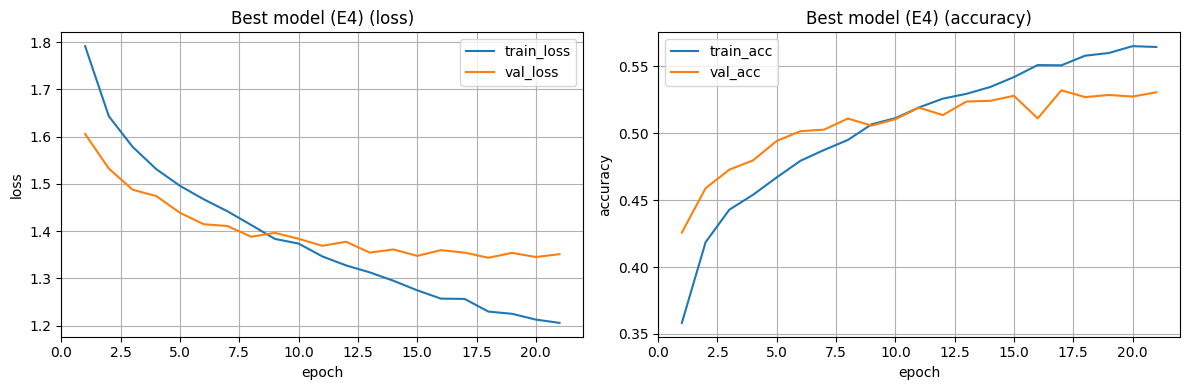

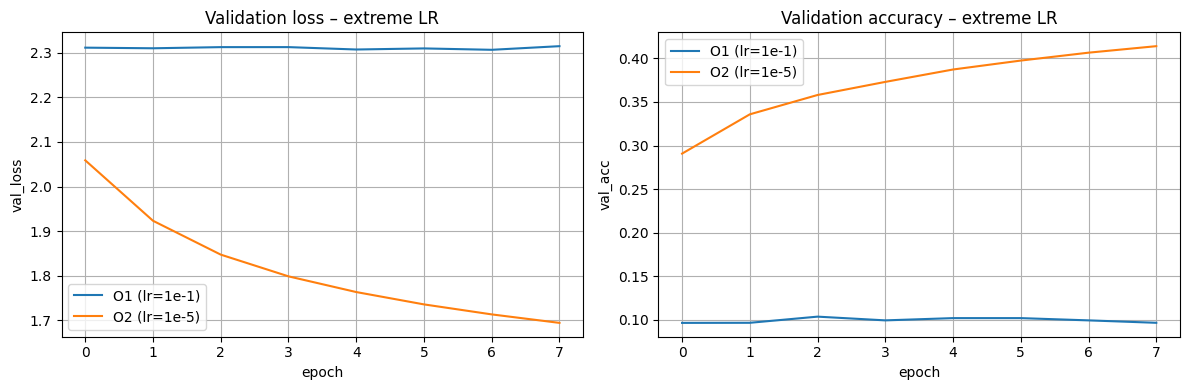

In [10]:
# 7. Графики

os.makedirs('./artifacts/figures', exist_ok=True)

def plot_curves(history, title, filename):
    epochs = range(1, len(history['train_loss'])+1)
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, history['train_loss'], label='train_loss')
    plt.plot(epochs, history['val_loss'], label='val_loss')
    plt.xlabel('epoch'); plt.ylabel('loss')
    plt.title(title + ' (loss)'); plt.legend(); plt.grid(True)
    plt.subplot(1,2,2)
    plt.plot(epochs, history['train_acc'], label='train_acc')
    plt.plot(epochs, history['val_acc'], label='val_acc')
    plt.xlabel('epoch'); plt.ylabel('accuracy')
    plt.title(title + ' (accuracy)'); plt.legend(); plt.grid(True)
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()

plot_curves(hist_e4, 'Best model (E4)', './artifacts/figures/curves_best.png')

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(hist_o1['val_loss'], label='O1 (lr=1e-1)')
plt.plot(hist_o2['val_loss'], label='O2 (lr=1e-5)')
plt.xlabel('epoch'); plt.ylabel('val_loss')
plt.title('Validation loss – extreme LR')
plt.legend(); plt.grid(True)
plt.subplot(1,2,2)
plt.plot(hist_o1['val_acc'], label='O1 (lr=1e-1)')
plt.plot(hist_o2['val_acc'], label='O2 (lr=1e-5)')
plt.xlabel('epoch'); plt.ylabel('val_acc')
plt.title('Validation accuracy – extreme LR')
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.savefig('./artifacts/figures/curves_lr_extremes.png', dpi=150)
plt.show()

In [11]:
## 8. Финальная оценка на тесте

test_loss, test_acc = evaluate(model_e4, test_loader, criterion, device)
print(f'Best model test loss: {test_loss:.4f}, test acc: {test_acc:.4f}')

Best model test loss: 1.3587, test acc: 0.5187
